In [1]:
import cv2
import os

# 데이터 분포

In [ ]:
dirs = os.listdir("1029_data")
## 인사
for d in [d for d in dirs if d not in ['training_data_left',"training_data_right"]]:
    path =  "1029_data/" + d + "/go"
    print(d,len(os.listdir(path)))

left 138
right 131
stop 164
straight 105
trumpet 132


In [18]:
root = "1029_data"

for d in ['training_data_left',"training_data_right"]:
    path1 = root + "/" +  d
    for state in os.listdir(path1):
        path =  path1 + "/" + state
        print(f'{path}"s len {len(os.listdir(path))}')

1029_data/training_data_left/go"s len 2817
1029_data/training_data_left/left"s len 1085
1029_data/training_data_left/right"s len 49
1029_data/training_data_left/stop"s len 64
1029_data/training_data_right/go"s len 2442
1029_data/training_data_right/left"s len 38
1029_data/training_data_right/right"s len 1067
1029_data/training_data_right/stop"s len 333


In [ ]:
go = 2817 + 2442
left = 1085 + 38
right = 1067  + 49
print("go", go)
print("left", left)
print("right", right)

go 5259
left 1123
right 1116


# img eda

In [7]:
import cv2
img = cv2.imread("1029_data/training_data_left/go/1761740132787.jpg")
img

array([[[ 58,  60,  60],
        [ 53,  54,  58],
        [ 48,  46,  58],
        ...,
        [156, 173, 159],
        [154, 173, 158],
        [154, 173, 158]],

       [[ 58,  60,  60],
        [ 53,  54,  58],
        [ 49,  47,  59],
        ...,
        [155, 172, 158],
        [154, 173, 158],
        [154, 173, 158]],

       [[ 56,  58,  59],
        [ 52,  52,  58],
        [ 49,  46,  61],
        ...,
        [155, 173, 156],
        [154, 171, 157],
        [154, 171, 157]],

       ...,

       [[ 32, 208, 201],
        [ 32, 208, 201],
        [ 32, 208, 201],
        ...,
        [ 39, 203, 198],
        [ 42, 202, 196],
        [ 41, 201, 195]],

       [[ 32, 208, 201],
        [ 32, 208, 201],
        [ 32, 208, 201],
        ...,
        [ 39, 204, 197],
        [ 42, 202, 196],
        [ 41, 201, 195]],

       [[ 33, 209, 202],
        [ 33, 209, 202],
        [ 32, 208, 201],
        ...,
        [ 39, 204, 197],
        [ 42, 202, 196],
        [ 41, 201, 195]]

In [8]:
cv2.imshow("img", img)
cv2.waitKey(0)   # 창을 1ms라도 유지
cv2.destroyAllWindows()

In [15]:
h,w = img.shape[:2]
img_half = img[h//4:, :]
cv2.imshow("img_half", img_half)
cv2.waitKey(0)   # 창을 1ms라도 유지
cv2.destroyAllWindows()


In [16]:
def img_preprocess(image):
    height, _, _ = image.shape
    image = image[int(height/2):,:,:]
    #image = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    image = cv2.resize(image, (200,66))
    #image = cv2.GaussianBlur(image,(5,5),0)
    #_,image = cv2.threshold(image,180,255,cv2.THRESH_BINARY)
    image = image / 255
    return image

In [17]:
cv2.imshow("img", img)
cv2.waitKey(0)   # 창을 1ms라도 유지
cv2.destroyAllWindows()

In [19]:
cv2.imshow("pre",img_preprocess(img))
cv2.waitKey(0)   # 창을 1ms라도 유지
cv2.destroyAllWindows()

In [32]:
import cv2
import numpy as np

def img_preprocess(image):
    height, _, _ = image.shape
    image = image[int(height/2):,:,:]  # 하단 절반만
    #가우시안 필터


    # 1️⃣ BGR → HSV 변환 (색상 기반 필터링에 적합)
    hsv = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # 2️⃣ 노란색 범위 정의 (H,S,V)
    # 일반 도로 환경 기준: 20~35° 정도가 yellow
    lower_yellow = np.array([15, 80, 80])
    upper_yellow = np.array([40, 255, 255])

    # 3️⃣ 노란색 마스크 생성
    mask = cv2.inRange(hsv, lower_yellow, upper_yellow)

    # 4️⃣ 원본에 마스크 적용 (노란 영역만 남김)
    yellow_lane = cv2.bitwise_and(image, image, mask=mask)
    # ✅ 4.5️⃣ 가우시안 블러 적용 (노이즈 제거)
    yellow_lane = cv2.GaussianBlur(yellow_lane, (9, 9), 0)

    # 5️⃣ 크기 축소 + 정규화
    image = cv2.resize(yellow_lane, (200, 66))
    image = image / 255.0
    return image

cv2.imshow("pre",img_preprocess(img))
cv2.waitKey(0)   # 창을 1ms라도 유지
cv2.destroyAllWindows()
    


📁 GO 폴더 예시 (10장 중 10장 시각화)


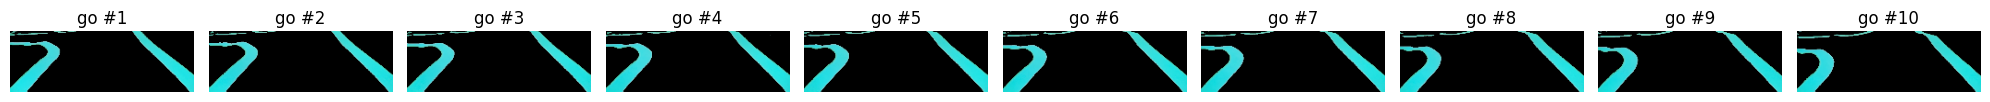


📁 LEFT 폴더 예시 (10장 중 10장 시각화)


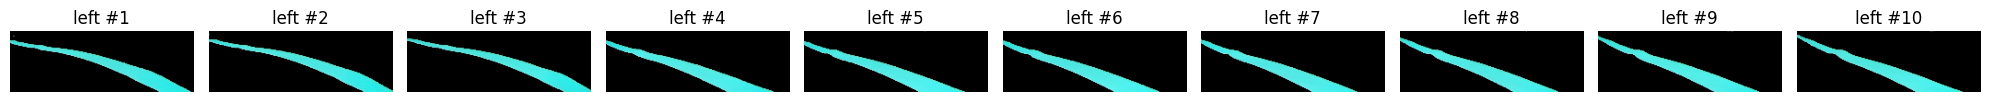


📁 RIGHT 폴더 예시 (10장 중 10장 시각화)


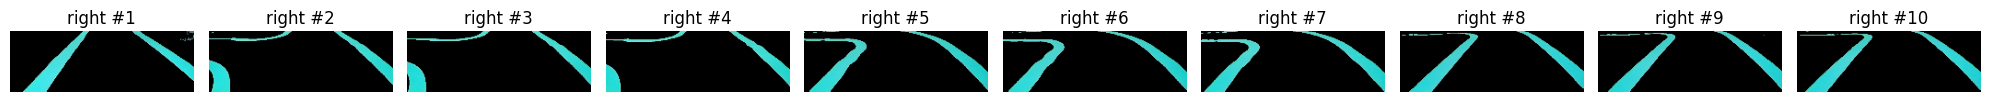

In [ ]:
import cv2
import os
import matplotlib.pyplot as plt


# --- 데이터 경로 ---
base_dir = "1029_data/training_data_left"
subdirs = ["go", "left", "right"]

# --- 각 폴더별로 10장씩 시각화 ---
for cls in subdirs:
    folder = os.path.join(base_dir, cls)
    files = sorted(os.listdir(folder))[10:20]  # 앞 10장만
    print(f"\n📁 {cls.upper()} 폴더 예시 ({len(files)}장 중 10장 시각화)")

    plt.figure(figsize=(20, 3))
    for i, file in enumerate(files):
        path = os.path.join(folder, file)
        img = cv2.imread(path)
        if img is None:
            continue 

        processed = img_preprocess(img)
        # 채널이 3개일 수도 있으니 흑백 변환
        plt.subplot(1, len(files), i+1)
        plt.imshow(processed, cmap='gray')
        plt.axis('off')
        plt.title(f"{cls} #{i+1}")
    plt.tight_layout()
    plt.show()
